# Analyses de données Netflix

## Jupyter Notebooks

## Pandas

In [12]:
import pandas as pd
import missingno as msno

### DataFame

In [135]:
df = pd.read_csv('netflix_titles.csv') # Charge les fichier csv au format dataframe pandas

In [21]:
print(df.head()) # display the 5 first items

0    As her father nears the end of his life, filmm...
1    After crossing paths at a party, a Cape Town t...
2    To protect his family from a powerful drug lor...
3    Feuds, flirtations and toilet talk go down amo...
4    In a city of coaching centers known to train I...
Name: description, dtype: object


In [25]:
print(df.tail()) # Display the 5 last items

8802    A political cartoonist, a crime reporter and a...
8803    While living alone in a spooky town, a young g...
8804    Looking to survive in a world taken over by zo...
8805    Dragged from civilian life, a former superhero...
8806    A scrappy but poor boy worms his way into a ty...
Name: description, dtype: object


#### Informations du DataFrame

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


Observations: Toutes les entrées ont bien un index, un type et un titre. infos manquantes: 2634 directors nulls, 825 cast nulls, 831 country nulls, 10 date_added, 4 rating nulls, 3 durations nulls. Le tableau est composé de 11 colonnes (objets). Une colonne est au format int64. Le DataFrame utlilise 825.8 KB  environ (il peut être légèrement plus lourd)

### Afficher la dimensionnité du DataFrame

In [27]:
print('Nombre de (lignes, colonnes ) :', df.shape) # a structure tupple (observations, variables)

Nombre de lignes et de colonnes : (8807, 12)


### Afficher les noms des valiables

In [29]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### Afficher le types des colonnes

In [32]:
print('Types des colonnes: \n', df.dtypes)

Types des colonnes: 
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


Observation: 11 colonnes regroupent des données qualitatives , 1 seule des données quantitatives

### Recherche de données manquantes et indication en pourcentage.

In [36]:
missing_data = df.isnull().mean() * 100
print("Pourcentage de valeurs nulles: \n",missing_data.sort_values(ascending = False) )

Pourcentage de valeurs nulles: 
 director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64


Observations: 30 % des données des noms réalisateurs sont manquantes, environ 9 % des données concernant les données des pays et du casting sont manquantes

<Axes: >

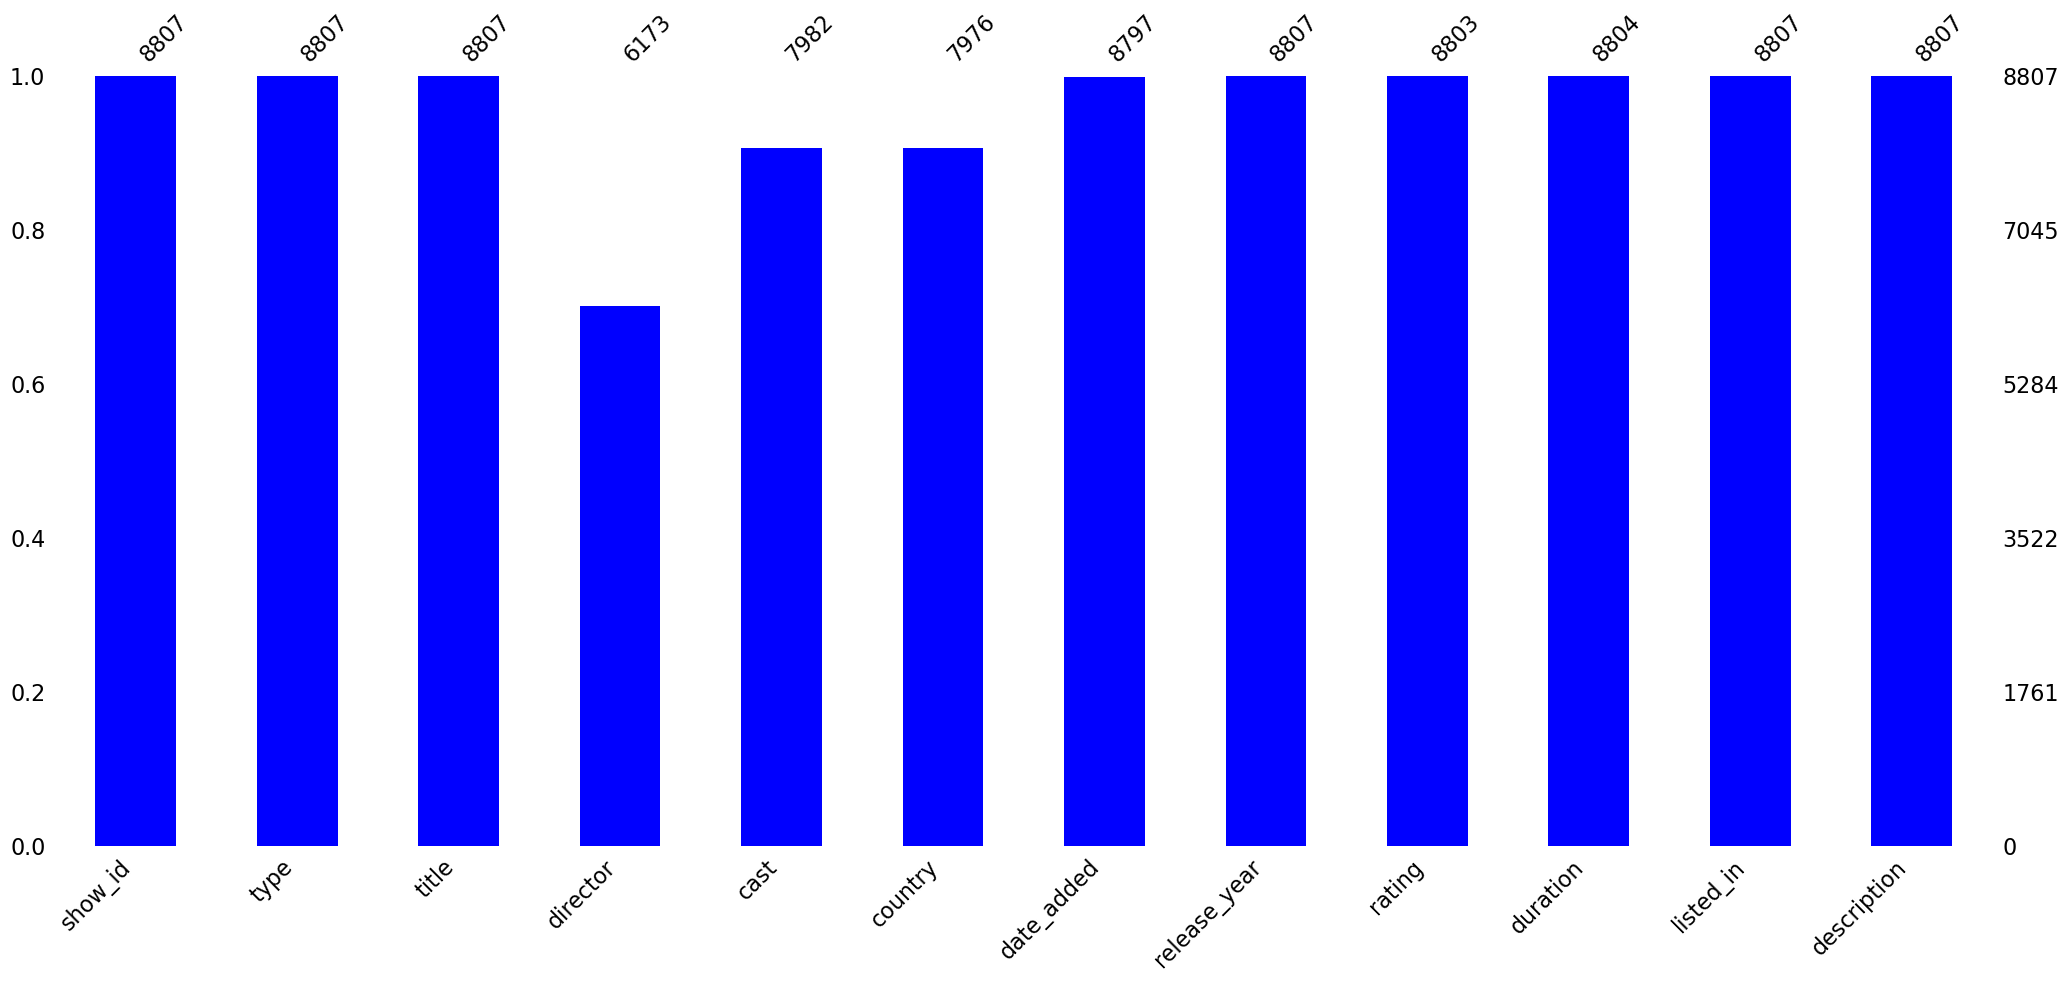

In [22]:
data = pd.read_csv('netflix_titles.csv')
df = pd.DataFrame(data)
msno.bar(df, color = 'blue')

### Quelques affichages à partir du DataFrame

Affichage aléatoire -> Ici l'index 1933

In [24]:
df.sample(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1933,s1934,TV Show,Wentworth,NaN,"Danielle Cormack, Nicole da Silva, Kate Atkins...",Australia,"September 30, 2020",2020,TV-MA,8 Seasons,"Crime TV Shows, TV Dramas",Bea Smith is locked up while awaiting trial fo...


Affichage par le nom (avec recherche en minuscule)

In [42]:
nom = "catch me if you can"
resultat = df[df['title'].str.lower() == nom.lower()]
print(resultat)

    show_id   type                title          director  \
329    s330  Movie  Catch Me If You Can  Steven Spielberg   

                                                  cast                country  \
329  Leonardo DiCaprio, Tom Hanks, Christopher Walk...  United States, Canada   

         date_added  release_year rating duration listed_in  \
329  August 1, 2021          2002  PG-13  142 min    Dramas   

                                           description  
329  An FBI agent makes it his mission to put cunni...  


Affichage du nom du film le plus récent

In [87]:
df['add_time'] = pd.to_datetime(df['date_added'], errors = 'coerce')

movies = df[df['type'].str.lower()== 'movie']

film_plus_recent = movies.loc[movies['add_time'].idxmax(), 'title']

print(film_plus_recent)

Dick Johnson Is Dead


Affichage du nom de la serie la plus récente

In [110]:
df['add_time'] = pd.to_datetime(df['date_added'], errors = 'coerce')

series = df[df['type'].str.lower()== 'tv show']

serie_plus_recente = series.loc[series['add_time'].idxmax(), 'title']

print(f"LA serie la plus récente: {serie_plus_recente}")

LA serie la plus récente: Blood & Water


In [122]:
df['add_time'] = pd.to_datetime(df['date_added'], errors = 'coerce')

series = df[df['type'].str.lower()== 'tv show']

max_date = series['add_time'].max()

serie_plus_recente = series[series['add_time']== max_date]

print(f"LES series les plus récente: \n {serie_plus_recente}")

LES series les plus récente: 
    show_id     type                                title         director  \
1       s2  TV Show                        Blood & Water              NaN   
2       s3  TV Show                            Ganglands  Julien Leclercq   
3       s4  TV Show                Jailbirds New Orleans              NaN   
4       s5  TV Show                         Kota Factory              NaN   
5       s6  TV Show                        Midnight Mass    Mike Flanagan   
8       s9  TV Show        The Great British Baking Show  Andy Devonshire   
10     s11  TV Show  Vendetta: Truth, Lies and The Mafia              NaN   

                                                 cast         country  \
1   Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...    South Africa   
2   Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...             NaN   
3                                                 NaN             NaN   
4   Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...       

### Convertir la variable duration des int en str

In [213]:
df.sample(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8384,s8385,Movie,The Last Exorcism,Daniel Stamm,"Patrick Fabian, Ashley Bell, Iris Bahr, Louis ...","France, United States","September 1, 2019",2010,PG-13,88,"Horror Movies, Independent Movies, Thrillers",Ready to expose his miraculous deeds as mere t...


In [211]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv('netflix_titles.csv')

# Fonction pour convertir la colonne 'duration' en minutes (int) ou en nombre de saisons (int) si applicable
def convert_duration_to_numeric(duration):
    if pd.isna(duration):  # Vérifier si la valeur est NaN
        return duration  # Retourner NaN sans modification
    elif isinstance(duration, str):
        duration = duration.strip()
        if duration.endswith('min'):
            # Extraire la partie numérique et convertir en entier (minutes)
            numeric_part = duration.replace('min', '').strip()
            if numeric_part.isdigit():
                return int(numeric_part)
        elif 'Season' in duration:
            # Extraire la partie numérique et convertir en entier (saisons)
            numeric_part = ''.join(filter(str.isdigit, duration))
            if numeric_part.isdigit():
                return int(numeric_part)
    # Laisser les autres valeurs inchangées
    return duration

# Appliquer la fonction à la colonne 'duration'
df['duration'] = df['duration'].apply(convert_duration_to_numeric).astype('Int64')

print(df.sample(1))



     show_id     type     title director  \
2184   s2185  TV Show  Get Even      NaN   

                                                   cast         country  \
2184  Kim Adis, Mia McKenna-Bruce, Bethany Antonia, ...  United Kingdom   

         date_added  release_year rating  duration  \
2184  July 31, 2020          2020  TV-PG         1   

                                              listed_in  \
2184  British TV Shows, Crime TV Shows, Internationa...   

                                            description  
2184  In a secret act of skillful revenge, four priv...  


In [209]:
df = pd.read_csv('netflix_titles.csv')
df['listed_in'] = (
    df['listed_in']
    .astype(str)  
    .str.split(",")  
    .apply(lambda x: [s.strip() for s in x if s.strip() != ''])  
)

print(df.sample(1))

     show_id   type            title         director  \
1903   s1904  Movie  An Ordinary Man  Brad Silberling   

                                               cast                country  \
1903  Ben Kingsley, Hera Hilmar, Peter Serafinowicz  Serbia, United States   

           date_added  release_year rating duration            listed_in  \
1903  October 1, 2020          2017      R   91 min  [Dramas, Thrillers]   

                                            description  
1903  A war criminal in hiding begins to suspect tha...  
